# 0. Graph implementation

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

class MyGraph:
    def __init__(self, n_vertices, graph_type = 'undirected', weighted = False):
        self.n_vertices = n_vertices
        self.n_edges = 0
        self.graph_type = graph_type
        self.weighted = weighted
        self.edges = [[] for _ in range(n_vertices + 1)]
        
    def add_edge(self, u, v, weight = 1):
        if u < 0 or u >= self.n_vertices or v < 0 or v >= self.n_vertices:
            raise ValueError(f"Vertex index out of bounds: u={u}, v={v}")
        
        if self.weighted:
            self.edges[u].append((v, weight))
            if self.graph_type == 'undirected':
                self.edges[v].append((u, weight))
        else:
            self.edges[u].append(v)
            if self.graph_type == 'undirected':
                self.edges[v].append(u)
        
        self.n_edges += 1
        
    def add_edges(self, edge_list):
        for edge in edge_list:
            if self.weighted:
                u, v, weight = edge
                self.add_edge(u, v, weight)
            else:
                u, v = edge
                self.add_edge(u, v)
        
    def get_outgoing_edges(self, u):
        if u < 0 or u >= self.n_vertices:
            raise ValueError(f"Vertex index out of bounds: u={u}")
        return self.edges[u]
    
        
    def get_neighbors(self, u):
        if u < 0 or u >= self.n_vertices:
            raise ValueError(f"Vertex index out of bounds: u={u}")
        return [v for v, _ in self.edges[u]] if self.weighted else self.edges[u]
    
    def get_all_edges(self):
        all_edges = []
        for u in range(self.n_vertices):
            for edge in self.edges[u]:
                if self.weighted:
                    v, weight = edge
                    all_edges.append((u, v, weight))
                else:
                    all_edges.append((u, edge))
        return all_edges
    
    def get_vertices(self):
        return list(range(self.n_vertices))
    
    def visualize(self):
        G = nx.DiGraph() if self.graph_type == 'directed' else nx.Graph()
        edge_list = self.get_all_edges()
        
        if self.weighted:
            G.add_weighted_edges_from(edge_list)
        else:
            G.add_edges_from(edge_list)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, seed=42)
        
        nx.draw(G, pos, 
                with_labels=True,
                node_color='lightblue', 
                node_size=1500, 
                font_size=15, 
                font_weight='bold',
                edge_color='gray')
        
        if self.weighted:
            edge_labels = nx.get_edge_attributes(G, 'weight')
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        plt.title(f"Graph Visualization ({self.graph_type}, weighted={self.weighted})")
        plt.show()
    
    def __str__(self):
        result = []
        for i in range(self.n_vertices):
            if self.weighted:
                edges_str = ', '.join([f"{v}(weight={w})" for v, w in self.edges[i]])
            else:
                edges_str = ', '.join(map(str, self.edges[i]))
            result.append(f"{i}: {edges_str}")
        return "\n".join(result)
    

# Max Flow

# 1. Definition of Flow Network
+ We define a **flow network** as a directed graph $G = (V, E, c, s, t)$, where:
  + $V$ is the set of vertices
  + $E$ is the set of edges
  + $c: Each edge $(u,v) \in E$ has a non-negative **capacity** $c(u,v)$
  + $s$ is the **source** vertex
  + $t$ is the **sink** vertex
+ Then we definition the **Flow**:
  + A **flow** in a flow network is a function $f: E \rightarrow \mathbb{R}$ which associate a non-negative real number to each edge and satisfies the following properties:
    1. **Capacity Constraint**: For every edge $(u,v) \in E$, the flow must satisfy $0 \leq f(u,v) \leq c(u,v)$.
    2. **Flow Conservation**: For every vertex $v \in V$ except for the source $s$ and sink $t$, the total flow into $v$ must equal the total flow out of $v$. 
       + Formally, $\sum_{u:(u,v) \in E} f(u,v) = \sum_{w:(v,w) \in E} f(v,w)$.
  + The **value** of a flow $v(f)$ is defined as the total flow out of the source $s$, which is also equal to the total flow into the sink $t$.

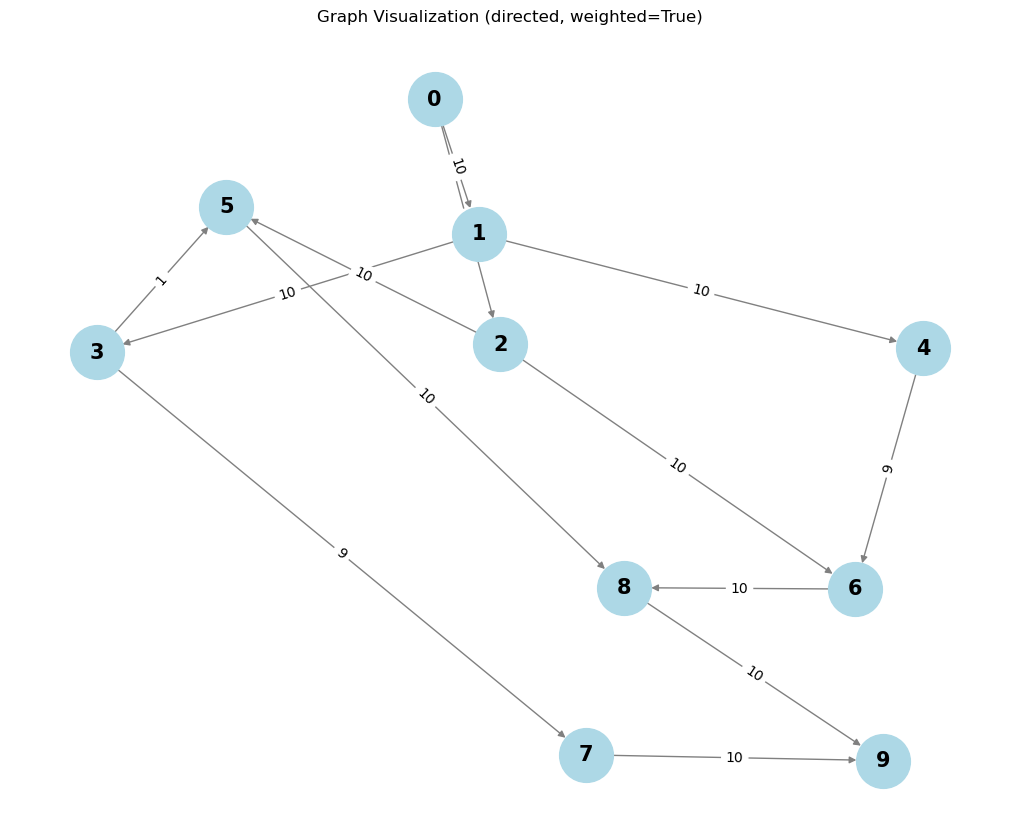

In [2]:
example = MyGraph(10, 'directed', True)
edges = [
    (0, 1, 10),
    (0, 2, 10),
    
    # 第一层到第二层
    (1, 3, 10),
    (1, 4, 10),
    (2, 5, 10),
    (2, 6, 10),
    
    # 第二层交错连接 (关键瓶颈区域)
    (3, 5, 1),  # 这条边容量很小，制造瓶颈
    (3, 7, 9),
    (4, 6, 9),
    (5, 8, 10),
    (6, 8, 10),
    
    # 汇入汇点
    (7, 9, 10),
    (8, 9, 10)
]
s = 0
t = 9
excepted_max_flow = 19
example.add_edges(edges)
example.visualize()

# 2. Algorithms

## 2.1 Ford-Fulkerson Algorithm
+ Core Idea: Repeatedly greedly find **augmenting paths**.
+ We firstly define the **residual graph** $G_f$ for a flow $f$ in a flow network $G$:
  + $G_f$ donates the remaining capacity of the edges after considering the current flow $f$.
  + There are two types of edges in the residual graph:
    1. **Forward edges**: $\forall(u,v) \in E$, if $f(u,v) < c(u,v)$, then there is a forward edge $(u,v)$ in $G_f$ with capacity $c_f(u,v) = c(u,v) - f(u,v)$.
    2. **Backward edges**: $\forall(u,v) \in E$, if $f(u,v) > 0$, then there is a backward edge $(v,u)$ in $G_f$ with capacity $c_f(v,u) = f(u,v)$.
+ An **augmenting path** is a path from the source $s$ to the sink $t$ in the residual graph $G_f$ that has positive capacity on all edges.

### Algorithm Steps:
1. Initialize the flow $f$ to be zero on all edges.
2. Struct the residual graph $G_f$.
3. While there exists an augmenting path $P$ from $s$ to $t$ in $G_f$:
   1. Find an augmenting path $P$ from $s$ to $t$ in $G_f$.
   2. Compute the **bottleneck capacity** $c_f(P)$ of the path $P$, which is the minimum residual capacity along the path.
   3. Augment the flow $f$ along the path $P$ by adding $c_f(P)$ to the flow, and update the $G_f$ accordingly.
4. Return the flow $f$ and its value.

### Correctness:
We define:
+ **s-t Cut**:
  + A partition of $V$ into two subset $S$ and $T$, s.t. $s \in S$ and $t \in T$.
  + The **capacity** of the cut $(S,T)$ is defined as:
  $$cut(S,T) = \sum_{u \in S, v \in T} c(u,v)$$
+ Property:
  + **Flow Value Lemma**: $\forall f$, the value of the flow $v(f)$ is equal to the net flow across any s-t cut $(S,T)$, i.e.
    + $v(f) = \sum_{\text{e is out of S}}(f(e)) - \sum_{\text{e is into S}}(f(e))$.
    + proof: All flow that leaves $S$ must eventually reach $t$. So the value of the flow is equal to the net flow across the cut.
  + **Weak Duality**: $\max_f v(f) \leq \min_{(S,T)} cut(S,T)$.
    + proof: $\forall f, \forall (S,T)$, we have:
    $$
    \begin{aligned}
    v(f) &= \sum_{\text{e is out of S}}(f(e)) - \sum_{\text{e is into S}}(f(e))(\ge 0)\\
    &\leq \sum_{\text{e is out of S}}(f(e))\\
    &\leq \sum_{\text{e is out of S}}(c(e))\\
    &= cut(S,T)
    \end{aligned}
    $$
By those definitions and properties, we can prove the correctness of the Ford-Fulkerson algorithm:
+ **Max-Flow Min-Cut Theorem**:
  + When the algorithm terminates, there is no augmenting path in the residual graph $G_f$.
  + Then we can structure a cut $(S,T)$ so that $cut(S, T) = v(f)$, which means that the flow is maximum and the cut is minimum.
    + The s-t cut $(S,T)$ can be constructed as follows:
      1. $S$ is the set of vertices reachable from $s$ in the residual graph $G_f$.
      2. $T = V \setminus S$.
      3. Because there is no augmenting path, we have $t\in T$.
    + $\forall e \text{ is out of S in G}$, $e\notin G_f$ means that $f(e) = c(e)$.
    + $\forall e \text{ is into S in G}$, $e\in G_f$ means that $f(e) = 0$.
    + So we have:
    $$
    \begin{aligned}
    cut(S,T) &= \sum_{\text{e is out of S}}(c(e))\\
    &= \sum_{\text{e is out of S}}(f(e))\\
    &= v(f)
    \end{aligned}
    $$
  + Therefore, the flow $f$ is a maximum flow and the cut $(S,T)$ is a minimum cut.

### Time Complexity:

+ The algorithm can guarantee increase the value of the flow by at least 1 in each iteration if all capacities are integers.
  + And we know that the maximum flow value is least than all capacities out of the source, which is at most $E\cdot C_{max}$, where $C_{max}$ is the maximum capacity of any edge.
+ The time complexity of the Ford-Fulkerson algorithm depends on how we find the augmenting paths.

### Different way of finding augmenting paths:
1. **DFS**:
   + Time complexity of $T_{path}$ is $O(V+E)$.
   + So the overall time complexity is $O(E\cdot C_{max} \cdot (V+E))$.
2. **BFS** (**Edmonds-Karp Algorithm**):
   + Time complexity of $T_{path}$ is $O(V+E)$.
   + Proof:
   + **Distance Lemma**: 
     + BFS guaranteed that the length of the shortest augmenting path won'e decrease after each augmentation.
     + Proof:
       + Core idea of proof: Each augmentation will either remove a forward edge or add a backward edge. The only change is we may need to by pass the removed edge.
       + We prove by induction on the number of augmentation.
       + $d_{f_i}(v)$ donates the distance(the number of edges) from $s$ to $v$ in the residual graph $G_{f_i}$ after $i$-th augmentation.
       + Base case: $i=0$, the distance is the same as the original graph, so the lemma holds.
       + Induction step:
         + We assume that the lemma holds for $i=k$, we will show that it also holds for $i=k+1$.
         + Suppose that $d_{f_k}(v) > d_{f_{k+1}}(v)$, we suppose $u$ is the previously vertex of $v$ in the $k+1$-th augmenting path.  
         + So we have $d_{f_{k+1}}(u) = d_{f_{k+1}}(v) - 1 < d_{f_k}(v) - 1 = d_{f_k}(u)$.
         + We have two case:
           1. The edge $(u,v)$ exists in $G_{f_k}$, then we have $d_{f_k}(v) \leq d_{f_k}(u) + 1$, which contradicts with the previous inequality.
           2. The edge $(u,v)$ doesn't exist in $G_{f_k}$, then it must be a backward edge.
              1. i.e. the forward edge $(v,u)$ is removed in $i$-th augmentation, which means that $(v, u)$ must be in the $k$-th augmenting path. So we have $d_{f_k}(u) < d_{f_k}(v)$, which contradicts with the previous inequality.
           3. So we have $d_{f_k}(v) \leq d_{f_{k+1}}(v)$.
   + We define the **critical edge**: the edge with the minimum residual capacity along the augmenting path. So we have:
   + **Critical Edge Lemma**:
     + $\forall e \in E$, $e$ can be a forwardcritical edge at most $V/2$ times, and can be a backward critical edge at most $V/2$ times too.
     + Proof:
       + Each time $e$ is a forward critical edge, it will be removed from the residual graph.
       + So it can only appears again iff it's a backward critical edge in the future.
       + In this process, the distance from $s$ to $e$ will increase by at least 2:
         + Originally, $e=(u, v)$ is a forward critical edge, so we have $d_{f_p}(u) \leq d_{f_p}(v) + 1$.
         + After the  q-th augmentation, $e$ is removed, so we have $d_{f_q}(u) \leq d_{f_q}(v) + 1$.
         + So we have $d_{f_q}(u) \leq d_{f_q}(v) + 1 \leq d_{f_p}(v) + 2 \leq d_{f_p}(u) + 2$.
       + The path is shorter than $V$, so $e$ can only be a forward critical edge at most $V/2$ times.
   + So the overall time complexity is $O(V\cdot E^2)$.
3. Scaling Max-Flow Algorithm: we will show at next part;


## 2.2 Scaling Max-Flow Algorithm
+ Core Idea: Instead of finding **any** augmenting path, we only find **large** augmenting paths.
+ Consider we set a threshold $\Delta$, and we only look for augmenting paths in the residual graph $G_f$ that have capacity at least $\Delta$.

### Algorithm Steps:
1. Initialize the flow $f$ to be zero on all edges, $\Delta$ to be the largest power of 2 that is less than or equal to $C_{max}$.
2. Initialize the residual graph $G_f$.
3. While $\Delta \geq 1$:
   1. Only consider the edges in $G_f$ that have capacity at least $\Delta$.
   2. While there exists an augmenting path $P$ from $s$ to $t$, do as in Ford-Fulkerson algorithm to augment the flow along $P$.
   3. If no such path exists, set $\Delta = \Delta / 2$.
4. Return the flow $f$ and its value.

The correctness is same as Ford-Fulkerson algorithm.

### Time Complexity:
1. The number of Phases: $O(\log C_{max})$
2. The number of augmentation per phase:
   + **Lemma**: In each phase, the flow will increase by at least $E\cdot \Delta$.
     + proof: 
       + Consider the residual graph $G_f(\Delta)$ after any phase. 
       + We cut the graph into two parts: $S$ is the set of vertices reachable from $s$ in $G_f(\Delta)$, and $T = V \setminus S$. 
       + $\forall e \text{ is out of S in G}$, $e\notin G_f(\Delta)$ means that the remaining capacity of $e$ is less than $\Delta$, which means that $f(e) > c(e) - \Delta$.
       + $\forall e \text{ is into S in G}$, $e\in G_f(\Delta)$ means that the remaining capacity of $e$ is at least $\Delta$, which means that $f(e) \geq \Delta$.
       + So we have:
       $$
       \begin{aligned}
       v(f) &= \sum_{\text{e is out of S}}(f(e)) - \sum_{\text{e is into S}}(f(e))\\
       &\geq \sum_{\text{e is out of S}}(c(e) - \Delta) - \sum_{\text{e is into S}}(\Delta)\\
       &\geq \sum_{\text{e is out of S}}(c(e)) - E\cdot \Delta\\
       &\geq E\cdot \Delta
       \end{aligned}
       $$
   + Note that each augmentation will increase the flow by at least $\Delta$, so the number of augmentation per phase is at most $O(\frac{E\cdot \Delta}{\Delta}) = O(E)$.
3. The time complexity of finding each augmenting path is $O(V+E)$.
4. So the overall time complexity is:
$$O(\log C_{max} \cdot E \cdot (V+E))=O(E^2 \log C_{max})$$

In [3]:
def dfs_find_augmenting_path(residual, cur, t, visited):
    if cur == t:
        return [cur], float('inf')
    visited[cur] = True
    for neighbor in residual.get_neighbors(cur):
        if visited[neighbor]:
            continue
        capacity = None
        for v, w in residual.edges[cur]:
            if v == neighbor:
                capacity = w
                break
        if capacity is not None and capacity > 0:
            result = dfs_find_augmenting_path(residual, neighbor, t, visited)
            if result is not None:
                path, path_capacity = result
                return [cur] +path, min(capacity, path_capacity)
    return None

def bfs_find_augmenting_path(residual, s, t, visited):
    from collections import deque
    queue = deque([(s, [s], float('inf'))])
    visited[s] = True
    while queue:
        cur, path, path_capacity = queue.popleft()
        if cur == t:
            return path, path_capacity
        for neighbor in residual.get_neighbors(cur):
            if visited[neighbor]:
                continue
            capacity = None
            for v, w in residual.edges[cur]:
                if v == neighbor:
                    capacity = w
                    break
            if capacity is not None and capacity > 0:
                visited[neighbor] = True
                queue.append((neighbor, path + [neighbor], min(capacity, path_capacity)))
    return None

def structure_initial_residual_graph(graph):
    residual = MyGraph(graph.n_vertices, graph_type='directed', weighted=True)
    for u, v, w in graph.get_all_edges():
        residual.add_edge(u, v, w)
        residual.add_edge(v, u, 0)
    return residual


def ford_fulkerson(graph, s, t, find_augmenting_path):
    count_paths = 0
    residual = structure_initial_residual_graph(graph)
    max_flow = 0
    while True:
        visited = [False] * graph.n_vertices
        result = find_augmenting_path(residual, s, t, visited)
        if result is None or result[1] == 0:
            break
        path, path_capacity = result
        count_paths += 1
        print(f"Augmenting path found: {path} with capacity {path_capacity}")
        max_flow += path_capacity
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            for idx, (vertex, w) in enumerate(residual.edges[u]):
                if vertex == v:
                    residual.edges[u][idx] = (vertex, w - path_capacity)
                    break
            for idx, (vertex, w) in enumerate(residual.edges[v]):
                if vertex == u:
                    residual.edges[v][idx] = (vertex, w + path_capacity)
                    break
    return {"max_flow": max_flow, "The number of augmenting paths founded": count_paths}

def scale_max_flow(graph, s, t, find_augmenting_path):
    cmax = max(w for _, _, w in graph.get_all_edges())
    delta = 1 << (cmax.bit_length() - 1)        
    count_paths = 0
    residual = structure_initial_residual_graph(graph)
    max_flow = 0
    while delta > 0:
        while True:
            visited = [False] * graph.n_vertices
            result = find_augmenting_path(residual, s, t, visited)
            if result is None or result[1] < delta:
                break
            path, path_capacity = result
            count_paths += 1
            print(f"Augmenting path found: {path} with capacity {path_capacity} (delta={delta})")
            max_flow += path_capacity
            for i in range(len(path) - 1):
                u, v = path[i], path[i + 1]
                for idx, (vertex, w) in enumerate(residual.edges[u]):
                    if vertex == v:
                        residual.edges[u][idx] = (vertex, w - path_capacity)
                        break
                for idx, (vertex, w) in enumerate(residual.edges[v]):
                    if vertex == u:
                        residual.edges[v][idx] = (vertex, w + path_capacity)
                        break
        delta //= 2
    return {"max_flow": max_flow, "The number of augmenting paths founded": count_paths}
    


print(f"Max flow: {ford_fulkerson(example, s, t, dfs_find_augmenting_path)}, the expected max flow is {excepted_max_flow}")
print("-"*32)
print(f"Max flow: {ford_fulkerson(example, s, t, bfs_find_augmenting_path)}, the expected max flow is {excepted_max_flow}")
print("-"*32)
print(f"Max flow: {scale_max_flow(example, s, t, bfs_find_augmenting_path)}, the expected max flow is {excepted_max_flow}")

        

Augmenting path found: [0, 1, 3, 5, 8, 9] with capacity 1
Augmenting path found: [0, 1, 3, 7, 9] with capacity 9
Augmenting path found: [0, 2, 5, 3, 1, 4, 6, 8, 9] with capacity 1
Augmenting path found: [0, 2, 5, 8, 9] with capacity 8
Max flow: {'max_flow': 19, 'The number of augmenting paths founded': 4}, the expected max flow is 19
--------------------------------
Augmenting path found: [0, 1, 3, 7, 9] with capacity 9
Augmenting path found: [0, 2, 5, 8, 9] with capacity 10
Max flow: {'max_flow': 19, 'The number of augmenting paths founded': 2}, the expected max flow is 19
--------------------------------
Augmenting path found: [0, 1, 3, 7, 9] with capacity 9 (delta=8)
Augmenting path found: [0, 2, 5, 8, 9] with capacity 10 (delta=8)
Max flow: {'max_flow': 19, 'The number of augmenting paths founded': 2}, the expected max flow is 19


# 3. Real World Applications